# Historical Pool Data — FinTech 590
Fetches daily historical TVL, APY, and impermanent loss for each pool in `data/top_pools.csv`.

**Run `defi_pipeline.ipynb` first** to generate the pool list.

Data source: [DeFiLlama Chart API](https://yields.llama.fi/docs) — free, no API key required.  
Coverage: daily data from **March 2022 → present** (~1,400+ data points per pool).

## 0. Imports

In [1]:
import time, pathlib
import requests
import pandas as pd

POOLS_CSV    = pathlib.Path("data/top_pools.csv")
HISTORY_CSV  = pathlib.Path("data/pool_history.csv")
CHART_URL    = "https://yields.llama.fi/chart/"
DELAY        = 0.5   # be polite to the API

print("Ready.")

Ready.


## 1. Load Pool List

In [2]:
pools = pd.read_csv(POOLS_CSV)
print(f"Loaded {len(pools)} pools from {POOLS_CSV}")
pools[["address", "token0", "token1", "fee_tier", "llama_id"]]

Loaded 20 pools from data\top_pools.csv


,address,token0,token1,fee_tier,llama_id
0,0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640,USDC,WETH,500,665dc8bc-c79d-4800-97f7-304bf368e547
1,0x4e68Ccd3E89f51C3074ca5072bbAC773960dFa36,WETH,USDT,3000,fc9f488e-8183-416f-a61e-4e5c571d4395
2,0x4585FE77225b41b697C938B018E2Ac67Ac5a20c0,WBTC,WETH,500,d59a5728-d391-4989-86f6-a94e11e0eb3b
3,0xCBCdF9626bC03E24f779434178A73a0B4bad62eD,WBTC,WETH,3000,c5599b3a-ea73-4017-a867-72eb971301d1
4,0xe8f7c89C5eFa061e340f2d2F206EC78FD8f7e124,WBTC,CBBTC,100,c0bbcf6c-9454-4773-a19f-c6486484c287
5,0x99ac8cA7087fA4A2A1FB6357269965A2014ABc35,WBTC,USDC,3000,bbecbf69-a4f7-43e3-8b72-de180d106e2c
6,0x3416cF6C708Da44DB2624D63ea0AAef7113527C6,USDC,USDT,100,e737d721-f45c-40f0-9793-9f56261862b9
7,0x9Db9e0e53058C89e5B94e29621a205198648425B,WBTC,USDT,3000,2608e751-41d4-47db-9b9c-4bf3a757fc1b
8,0xbAFeAd7c60Ea473758ED6c6021505E8BBd7e8E5d,AUSD,USDC,100,458a64c5-2f64-4ca6-8be7-41b8aef029eb
9,0x8ad599c3A0ff1De082011EFDDc58f1908eb6e6D8,USDC,WETH,3000,49717ee2-9808-4288-b76d-e658195b7979


## 2. Fetch Historical Data

For each pool, calls `yields.llama.fi/chart/{llama_id}` which returns daily snapshots with:

| Field | Description |
|-------|-------------|
| `tvl_usd` | Total value locked (USD) |
| `apy` | Total APY (fees + rewards) |
| `apy_base` | APY from trading fees only |
| `apy_base_7d` | 7-day rolling average base APY |
| `il_7d` | 7-day impermanent loss (%) |

In [3]:
all_records = []

for _, pool in pools.iterrows():
    label = f"{pool['token0']}/{pool['token1']} {pool['fee_tier']/1e4:.2f}%"
    print(f"  Fetching {label} ...", end="", flush=True)

    try:
        r = requests.get(CHART_URL + pool["llama_id"], timeout=30)
        r.raise_for_status()
        data = r.json().get("data", [])

        for point in data:
            all_records.append({
                "address":    pool["address"],
                "token0":     pool["token0"],
                "token1":     pool["token1"],
                "fee_tier":   pool["fee_tier"],
                "date":       point["timestamp"][:10],
                "tvl_usd":    point.get("tvlUsd"),
                "apy":        point.get("apy"),
                "apy_base":   point.get("apyBase"),
                "apy_base_7d": point.get("apyBase7d"),
                "il_7d":      point.get("il7d"),
            })

        print(f"  {len(data)} days")

    except Exception as e:
        print(f"  ERROR: {e}")

    time.sleep(DELAY)

print(f"\nTotal records collected: {len(all_records):,}")

  Fetching USDC/WETH 0.05% ...  1429 days
  Fetching WETH/USDT 0.30% ...  1449 days
  Fetching WBTC/WETH 0.05% ...  1449 days
  Fetching WBTC/WETH 0.30% ...  1449 days
  Fetching WBTC/CBBTC 0.01% ...  524 days
  Fetching WBTC/USDC 0.30% ...  1429 days
  Fetching USDC/USDT 0.01% ...  1429 days
  Fetching WBTC/USDT 0.30% ...  1449 days
  Fetching AUSD/USDC 0.01% ...  101 days
  Fetching USDC/WETH 0.30% ...  1429 days
  Fetching LINK/WETH 0.30% ...  1449 days
  Fetching USDM/USDT 0.05% ...  860 days
  Fetching WM/USDC 0.01% ...  535 days
  Fetching WBTC/USDT 0.05% ...  710 days
  Fetching TBTC/WBTC 0.01% ...  591 days
  Fetching UNI/WETH 0.30% ...  1449 days
  Fetching WETH/WEETH 0.05% ...  775 days
  Fetching USDT/USDF 0.01% ...  378 days
  Fetching WBTC/SOLVBTC 0.05% ...  564 days
  Fetching OHM/SUSDS 0.30% ...  476 days

Total records collected: 19,924


## 3. Save to CSV

In [4]:
df = pd.DataFrame(all_records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["address", "date"]).reset_index(drop=True)

df.to_csv(HISTORY_CSV, index=False)

print(f"Saved {len(df):,} rows to {HISTORY_CSV}")
print(f"Date range : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Pools      : {df['address'].nunique()}")
print()
df.head(10)

Saved 19,924 rows to data\pool_history.csv
Date range : 2022-03-27  →  2026-03-22
Pools      : 20



,address,token0,token1,fee_tier,date,tvl_usd,apy,apy_base,apy_base_7d,il_7d
0,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-02,5896592,0.0,0.0,0.0,-27.56798
1,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-03,5888587,0.0,0.0,0.0,-0.02329
2,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-04,6263800,0.0,0.0,0.0,-42.50033
3,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-05,6279582,0.0,0.0,0.0,-0.16622
4,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-06,6829915,0.0,0.0,0.0,-100.00000
5,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-07,6983517,0.0,0.0,0.0,-100.00000
6,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-08,6952755,0.0,0.0,0.0,-100.00000
7,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-09,6930175,0.0,0.0,0.0,-100.00000
8,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-10,6509238,0.0,0.0,0.0,-100.00000
9,0x0858e2B0F9D75f7300B38D64482aC2C8DF06a755,OHM,SUSDS,3000,2024-12-11,6845963,0.0,0.0,0.0,-100.00000


## 4. Quick Sanity Checks

In [5]:
# Records per pool
print("Days of history per pool:")
summary = (
    df.groupby(["token0", "token1", "fee_tier"])
    .agg(days=("date", "count"), earliest=("date", "min"), latest=("date", "max"))
    .reset_index()
)
summary["fee_pct"] = summary["fee_tier"] / 1e4
summary.drop(columns="fee_tier", inplace=True)
print(summary.to_string(index=False))

Days of history per pool:
token0  token1  days   earliest     latest  fee_pct
  AUSD    USDC   101 2025-04-11 2026-03-22     0.01
  LINK    WETH  1449 2022-03-27 2026-03-22     0.30
   OHM   SUSDS   476 2024-12-02 2026-03-22     0.30
  TBTC    WBTC   591 2024-08-09 2026-03-22     0.01
   UNI    WETH  1449 2022-03-27 2026-03-22     0.30
  USDC    USDT  1429 2022-03-27 2026-03-22     0.01
  USDC    WETH  1429 2022-03-27 2026-03-22     0.05
  USDC    WETH  1429 2022-03-27 2026-03-22     0.30
  USDM    USDT   860 2023-11-08 2026-03-22     0.05
  USDT    USDF   378 2025-02-23 2026-03-20     0.01
  WBTC   CBBTC   524 2024-10-15 2026-03-22     0.01
  WBTC SOLVBTC   564 2024-09-05 2026-03-22     0.05
  WBTC    USDC  1429 2022-03-27 2026-03-22     0.30
  WBTC    USDT   710 2023-04-01 2026-03-22     0.05
  WBTC    USDT  1449 2022-03-27 2026-03-22     0.30
  WBTC    WETH  1449 2022-03-27 2026-03-22     0.05
  WBTC    WETH  1449 2022-03-27 2026-03-22     0.30
  WETH    USDT  1449 2022-03-27 2026-0

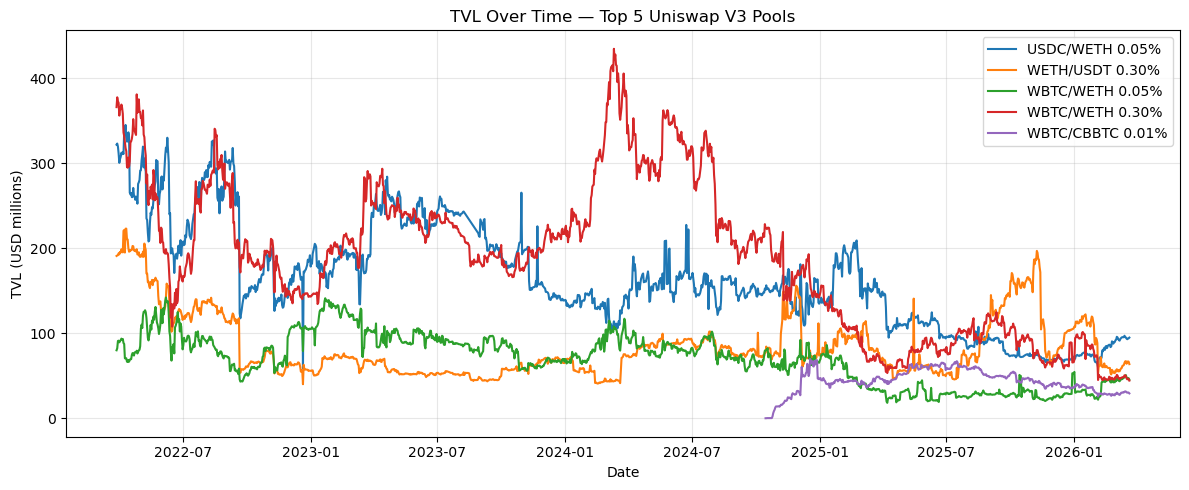

Chart saved to data/tvl_history.png


In [6]:
# TVL over time for top 5 pools by current TVL
import matplotlib.pyplot as plt

top5 = pools.head(5)["address"].tolist()
fig, ax = plt.subplots(figsize=(12, 5))

for addr in top5:
    subset = df[df["address"] == addr]
    row    = pools[pools["address"] == addr].iloc[0]
    label  = f"{row['token0']}/{row['token1']} {row['fee_tier']/1e4:.2f}%"
    ax.plot(subset["date"], subset["tvl_usd"] / 1e6, label=label)

ax.set_title("TVL Over Time — Top 5 Uniswap V3 Pools")
ax.set_ylabel("TVL (USD millions)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/tvl_history.png", dpi=150)
plt.show()
print("Chart saved to data/tvl_history.png")